<a href="https://colab.research.google.com/github/Misbahul624/-Hybrid-Multi-Axis-Pauli-Hamiltonian-Mapping-for-Weighted-and-Unweighted-Quantum-Opt../blob/main/QUANTUM_COMPUTING_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install qiskit qiskit-optimization networkx matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.0/664.0 kB 14.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 109.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.1 MB/s eta 0:00:00
  Created wheel for docplex: filename=docplex-2.32.264-py3-none-any.whl size=703859 sha256=9e5da33b1045146f6350cefd3a2940b82f5314ee7449c07646e5cc14c7f95fe0
  Stored in directory: /root/.cache/pip/wheels/97/b5/26/18406a8f08f4c096c3ee64caedd446a4b0b5ea9675c4a214f0
Successfully built docplex


In [2]:
pip install qiskit

In [3]:
pip install qiskit qiskit-aer networkx matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.2 MB/s eta 0:00:00


In [4]:
pip install qiskit qiskit-aer

In [5]:
pip install qiskit_aer

 PRODUCTION-GRADE QAOA SUITE: WEIGHTED GRAPH SYSTEM DASHBOARD   

Select Graph Topology Type:
1. Cycle Graph (Connected Loop Ring)
2. Random Disordered Graph (Erdos-Renyi)
3. Random Geometric Graph (Spatial Proximity Connection)
4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)
Enter choice (1, 2, 3, or 4): 1
Enter number of nodes/spins (2 to 10): 2
-> Generating Cycle Graph...

Enter QAOA circuit depth Layer p (1 to 5): 3
Enter measurement execution shots (100 to 4000): 2000
Enter max classical optimizer iterations (100 to 4000): 2000

Select Classical Core Optimizer Method:
1. COBYLA
2. Nelder-Mead
3. SLSQP
Enter choice (1, 2, or 3): 1

-> Activating Classical Optimization Loop Engine...
  [Iteration 001] Current Evaluated Cut Weight: 6.3840
  [Iteration 005] Current Evaluated Cut Weight: 3.3740
  [Iteration 010] Current Evaluated Cut Weight: 5.3795
  [Iteration 015] Current Evaluated Cut Weight: 6.7830
  [Iteration 020] Current Evaluated Cut Weight: 6.9860
  [Iteration 025] 

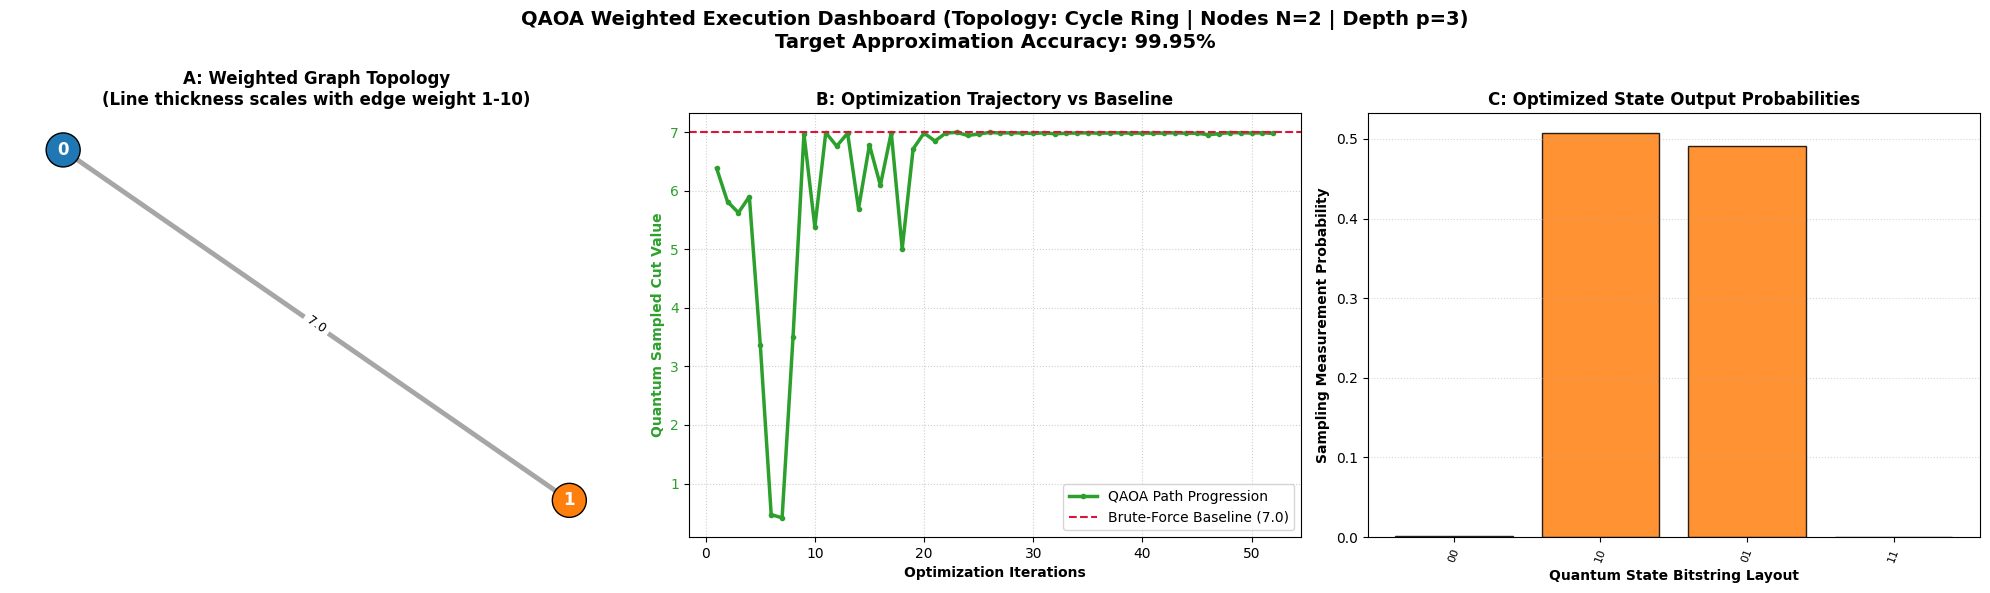

In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

print("=================================================================")
print(" PRODUCTION-GRADE QAOA SUITE: WEIGHTED GRAPH SYSTEM DASHBOARD   ")
print("=================================================================\n")

# 1. Advanced Graph Selection Profile (Geometric & Algorithmic Graphs)
print("Select Graph Topology Type:")
print("1. Cycle Graph (Connected Loop Ring)")
print("2. Random Disordered Graph (Erdos-Renyi)")
print("3. Random Geometric Graph (Spatial Proximity Connection)")
print("4. Barabasi-Albert Algorithmic Graph (Scale-Free Network)")
graph_choice = input("Enter choice (1, 2, 3, or 4): ").strip()

num_nodes = int(input("Enter number of nodes/spins (2 to 10): ").strip())
if num_nodes < 2 or num_nodes > 10:
    print("Warning: Bounds forced inside stable sandbox spectrum (Reset to N=6)")
    num_nodes = 6

# Initialize Topology
G = nx.Graph()
if graph_choice == "1":
    print(f"-> Generating Cycle Graph...")
    G = nx.cycle_graph(num_nodes)
elif graph_choice == "2":
    print(f"-> Generating Random Disordered Graph...")
    G = nx.fast_gnp_random_graph(num_nodes, p=0.5, seed=42)
elif graph_choice == "3":
    radius_val = float(input("Enter geometric connection radius (0.1 to 1.0, e.g., 0.5): ").strip())
    print(f"-> Generating Geometric Graph...")
    G = nx.random_geometric_graph(num_nodes, radius=radius_val, seed=42)
elif graph_choice == "4":
    m_edges = int(input(f"Enter number of edges to attach from a new node (1 to {num_nodes-1}): ").strip())
    print(f"-> Generating Algorithmic Scale-Free Graph...")
    G = nx.barabasi_albert_graph(num_nodes, m=m_edges, seed=42)
else:
    G = nx.cycle_graph(num_nodes)

# Assign RANDOM EDGE WEIGHTS from 1 to 10
np.random.seed(42)
for u, v in G.edges():
    G[u][v]['weight'] = float(np.random.randint(1, 11)) # Random integer 1 to 10

# 2. Compute the EXACT Weighted Maximum Cut (Brute-Force Baseline)
best_cost_exact = 0
best_bitstrings = []
for i in range(2**num_nodes):
    bitstr = format(i, f'0{num_nodes}b')
    current_cut_weight = 0
    for u, v, d in G.edges(data=True):
        if bitstr[u] != bitstr[v]: # Cut condition
            current_cut_weight += d['weight']
    if current_cut_weight > best_cost_exact:
        best_cost_exact = current_cut_weight
        best_bitstrings = [bitstr]
    elif current_cut_weight == best_cost_exact:
        best_bitstrings.append(bitstr)

# Map the Weighted Max-Cut problem to an Ising Hamiltonian Cost Function
pauli_list = []
for u, v, d in G.edges(data=True):
    pauli_str = list("I" * num_nodes)
    pauli_str[u] = "Z"
    pauli_str[v] = "Z"
    # Weight directly influences the energy coefficient
    pauli_list.append(("".join(pauli_str), -0.5 * d['weight']))
hamiltonian = SparsePauliOp.from_list(pauli_list)

constant_offset = 0.5 * sum(d['weight'] for u, v, d in G.edges(data=True))

# 3. Parameter Inputs for Circuit Configuration
p_depth = int(input("\nEnter QAOA circuit depth Layer p (1 to 5): ").strip())
if p_depth < 1 or p_depth > 5: p_depth = 1

max_shots = int(input("Enter measurement execution shots (100 to 4000): ").strip())
max_iters = int(input("Enter max classical optimizer iterations (100 to 4000): ").strip())

# 4. Choose Classical Target Optimizer Framework
print("\nSelect Classical Core Optimizer Method:")
print("1. COBYLA\n2. Nelder-Mead\n3. SLSQP")
opt_choice = input("Enter choice (1, 2, or 3): ").strip()
optimizer_method = "COBYLA" if opt_choice == "1" else ("Nelder-Mead" if opt_choice == "2" else "SLSQP")

# 5. Define Parameterized QAOA Execution Circuit Generator
def generate_qaoa_circuit(params, depth, nodes, graph):
    gammas = params[:depth]
    betas = params[depth:]

    qc = QuantumCircuit(nodes)
    qc.h(range(nodes))

    for layer in range(depth):
        for u, v, d in graph.edges(data=True):
            w = d['weight']
            qc.cx(u, v)
            qc.rz(2 * gammas[layer] * (-0.5 * w), v) # Dynamically scales with the edge weight
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(nodes))

    qc.measure_all()
    return qc

# 6. Cost Objective Function Tracker with Live Status Reporting
simulator = AerSimulator()
iteration_history = []
energy_history = []

def cost_objective(params):
    circuit = generate_qaoa_circuit(params, p_depth, num_nodes, G)
    result = simulator.run(circuit, shots=max_shots).result()
    counts = result.get_counts()

    total_hamiltonian_energy = 0
    for bitstr, count in counts.items():
        bitstr = bitstr[::-1]
        string_energy = 0
        for u, v, d in G.edges(data=True):
            w = d['weight']
            spin_u = 1 if bitstr[u] == '0' else -1
            spin_v = 1 if bitstr[v] == '0' else -1
            string_energy += -0.5 * w * spin_u * spin_v
        total_hamiltonian_energy += string_energy * (count / max_shots)

    current_max_cut_val = constant_offset + total_hamiltonian_energy
    current_iter = len(iteration_history) + 1
    iteration_history.append(current_iter)
    energy_history.append(current_max_cut_val)

    if current_iter % 5 == 0 or current_iter == 1:
        print(f"  [Iteration {current_iter:03d}] Current Evaluated Cut Weight: {current_max_cut_val:.4f}")

    return -current_max_cut_val

# 7. Start Classical Optimization Run Loop
print("\n-> Activating Classical Optimization Loop Engine...")
initial_parameters = [0.1] * (2 * p_depth)
res = minimize(cost_objective, initial_parameters, method=optimizer_method, options={'maxiter': max_iters})

# Final calculated stats extraction
optimized_params = res.x
final_gammas = optimized_params[:p_depth]
final_betas = optimized_params[p_depth:]
final_estimated_max_cut = -res.fun
approximation_ratio = final_estimated_max_cut / best_cost_exact if best_cost_exact > 0 else 1.0

# 8. Output Complete Metrics Reports
print("\n" + "="*57)
print("                 FINAL SIMULATION SUMMARY                ")
print("="*57)
print(f"Topology Pattern Choice  : {['Cycle','Random','Geometric','Barabasi-Albert'][int(graph_choice)-1]}")
print(f"Target Nodes Count (N)   : {num_nodes}")
print(f"Total Algorithm Steps    : {res.nfev}")
print(f"\nExact True Max Cut Weight: {best_cost_exact:.4f} (Solutions: {best_bitstrings})")
print(f"QAOA Sampled Max Cut     : {final_estimated_max_cut:.4f}")
print(f"APPROXIMATION RATIO (α)  : {approximation_ratio:.4f} ({(approximation_ratio*100):.2f}%)")
print("=========================================================\n")

# 9. Generate Complete Three-Panel Portfolio Dashboard
print("-> Compiling multi-panel graphic visualization dashboard...")
fig = plt.figure(figsize=(20, 6))

# Determine node colors based on the first optimal bitstring solution found
optimal_cut_string = best_bitstrings[0]
node_colors = ['#ff7f0e' if optimal_cut_string[node] == '1' else '#1f77b4' for node in G.nodes()]

# Extract edge weights to set line thicknesses dynamically in the graph plot
weights = [G[u][v]['weight'] for u, v in G.edges()]
normalized_thickness = [w / 2.0 for w in weights] # Scale down slightly so lines don't get overly fat

# Panel A: Weighted Topology Pattern Graph Visualization
ax1 = fig.add_subplot(1, 3, 1)
pos = nx.spring_layout(G, seed=42) if graph_choice != "3" else nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, ax=ax1, node_size=600, node_color=node_colors, edgecolors='black')
nx.draw_networkx_edges(G, pos, ax=ax1, width=normalized_thickness, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, ax=ax1, font_size=12, font_color='white', font_weight='bold')
# Overlay textual edge weight numbers on the lines
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax1, font_size=9)

ax1.set_title("A: Weighted Graph Topology\n(Line thickness scales with edge weight 1-10)", fontweight='bold')
ax1.axis('off')

# Panel B: Optimization Trajectory Line Graph
ax2 = fig.add_subplot(1, 3, 2)
color_track = '#2ca02c'
ax2.set_xlabel('Optimization Iterations', fontweight='bold')
ax2.set_ylabel('Quantum Sampled Cut Value', color=color_track, fontweight='bold')
ax2.plot(iteration_history, energy_history, color=color_track, linewidth=2.5, marker='.', label='QAOA Path Progression')
ax2.axhline(y=best_cost_exact, color='crimson', linestyle='--', linewidth=1.5, label=f'Brute-Force Baseline ({best_cost_exact})')
ax2.tick_params(axis='y', labelcolor=color_track)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')
ax2.set_title("B: Optimization Trajectory vs Baseline", fontweight='bold')

# Panel C: Final Quantum State Bitstring Probabilities
ax3 = fig.add_subplot(1, 3, 3)
optimal_circuit = generate_qaoa_circuit(optimized_params, p_depth, num_nodes, G)
final_counts = simulator.run(optimal_circuit, shots=max_shots).result().get_counts()

sorted_keys = sorted(final_counts.keys())
sorted_probabilities = [final_counts[k] / max_shots for k in sorted_keys]
cleaned_keys = [k[::-1] for k in sorted_keys]

bar_colors = ['#ff7f0e' if k in best_bitstrings else '#a6c8e0' for k in cleaned_keys]
ax3.bar(cleaned_keys, sorted_probabilities, color=bar_colors, edgecolor='black', alpha=0.85)
ax3.set_xlabel('Quantum State Bitstring Layout', fontweight='bold')
ax3.set_ylabel('Sampling Measurement Probability', fontweight='bold')
ax3.set_title("C: Optimized State Output Probabilities", fontweight='bold')
ax3.tick_params(axis='x', rotation=70, labelsize=8)
ax3.grid(axis='y', linestyle=':', alpha=0.5)

# Final Layout Render and Save File
graph_type_name = ['Cycle Ring', 'Random Erdos-Renyi', 'Spatial Geometric', 'Barabasi-Albert Scale-Free'][int(graph_choice)-1]
plt.suptitle(f"QAOA Weighted Execution Dashboard (Topology: {graph_type_name} | Nodes N={num_nodes} | Depth p={p_depth})\nTarget Approximation Accuracy: {approximation_ratio*100:.2f}%", fontweight='bold', fontsize=14)
fig.tight_layout()

output_filename = "qaoa_weighted_topology_dashboard.png"
plt.savefig(output_filename, dpi=300)
print(f"✔ Portfolio Dashboard graphic exported safely to: '{output_filename}'")
plt.show()